In [ ]:
# !pip install Sastrawi

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install optuna
!pip install requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 13.9 MB/s eta 0:00:00


### Sken 2 : indoBERT, GridSearch, Over Sampling

In [3]:
# Cell 1: Imports and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_curve, auc
)
from sklearn.preprocessing import LabelEncoder, label_binarize
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
import re
import warnings
import pickle
import os
from datetime import datetime
import json
from collections import Counter
import gc
from sklearn.utils.class_weight import compute_class_weight
import requests
import json
warnings.filterwarnings('ignore')

class Config:
    MODEL_NAME = "indobenchmark/indobert-large-p2"
    MAX_LENGTH = 128
    BATCH_SIZE = 32
    EVAL_BATCH_SIZE = 32
    NUM_EPOCHS = 10
    LEARNING_RATE = 4e-5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    TEST_SIZE = 0.2
    VAL_SIZE = 0.1
    RANDOM_STATE = 42
    DATA_PATH = '/content/drive/MyDrive/PRDECT-ID Dataset.csv'
    BASE_OUTPUT_PATH = '/content/drive/MyDrive/hasil_sken2'
    MODEL_SAVE_PATH = f"{BASE_OUTPUT_PATH}/fine_tuned_indobert_emotion"
    RESULTS_PATH = f"{BASE_OUTPUT_PATH}/results"
    LOGS_PATH = f"{BASE_OUTPUT_PATH}/logs"

In [4]:
# Cell 2: Environment Setup
def setup_environment():
    print("="*60)
    print("SETUP ENVIRONMENT")
    print("="*60)
    plt.style.use('default')
    sns.set_palette("husl")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"CUDA Version: {torch.version.cuda}")
        print(f"Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    for path in [Config.RESULTS_PATH, Config.LOGS_PATH, 'models']:
        os.makedirs(path, exist_ok=True)
    return device

device = setup_environment()

SETUP ENVIRONMENT
Device: cuda
GPU: Tesla T4
CUDA Version: 12.6
Available GPU Memory: 15.83 GB


LOADING, FILTERING, DAN EKSPLORASI DATA
Jumlah data awal (sebelum filter): 5,400

Jumlah data setelah filter: 5,400
Kolom: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']

Info Dataset (setelah filter):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Category         5400 non-null   object
 1   Product Name     5400 non-null   object
 2   Location         5400 non-null   object
 3   Price            5400 non-null   int64 
 4   Overall Rating   5400 non-null   int64 
 5   Number Sold      5400 non-null   int64 
 6   Total Review     5400 non-null   int64 
 7   Customer Rating  5400 non-null   int64 
 8   Customer Review  5400 non-null   object
 9   Sentiment        5400 non-null   object
 10  Emotion          5400 non-null  

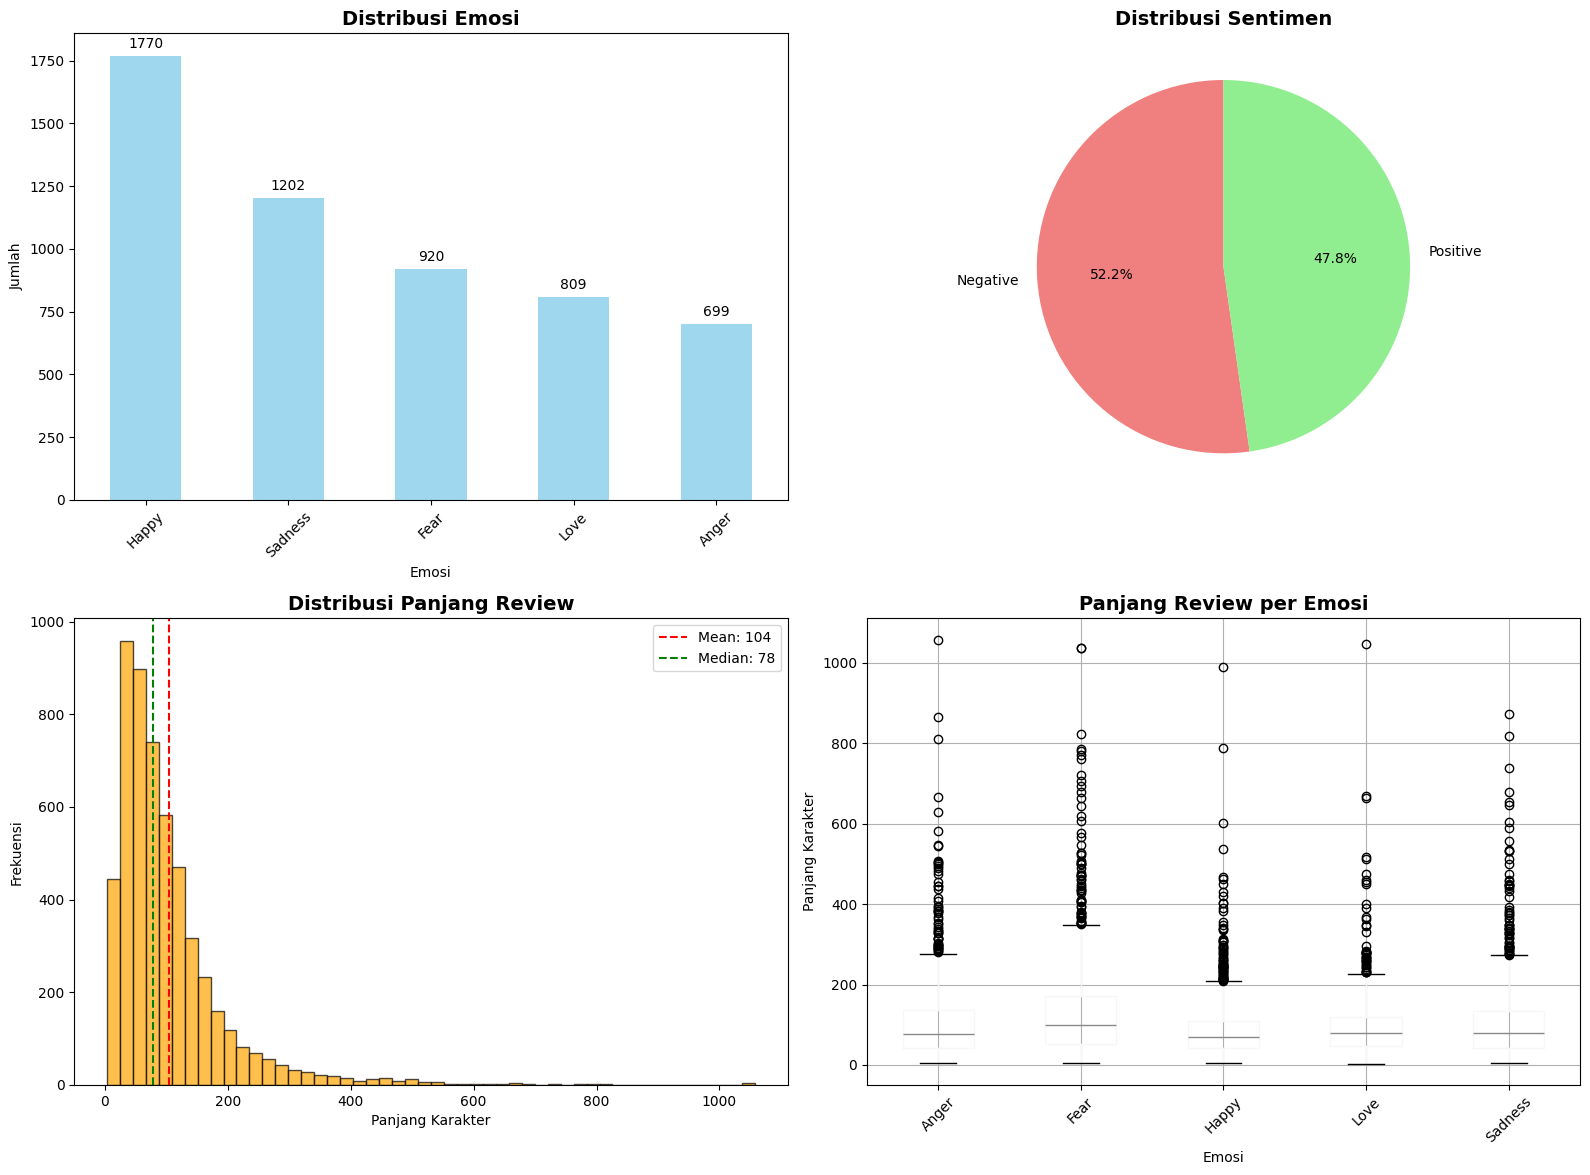


VISUALISASI PERBANDINGAN ANTAR KATEGORI UTAMA (Top 5)


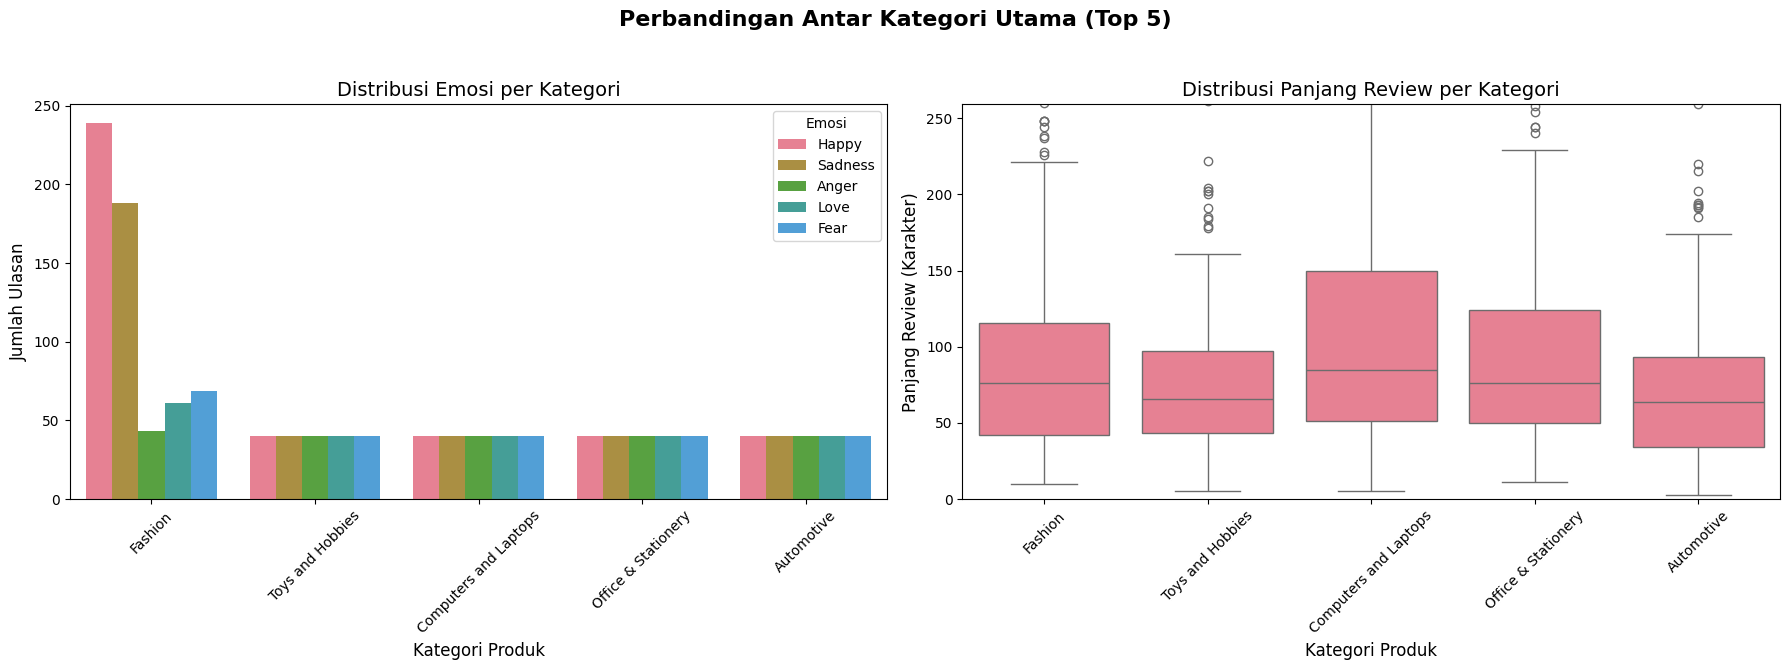


Contoh Teks untuk Setiap Emosi:

HAPPY:
  1. "Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah"
  2. "barang bagus dan respon cepat, harga bersaing dengan yg lain."

SADNESS:
  1. "Sangat kecewa. Baru 4 bulan scroll sudah rusak."
  2. "jelek, yg pasti jauh dari ori. mousepad jd ga bs dipakai kl di charger, jd getar parah. barang ga sesui foto, kayak barang lapak sebelah yg harga 80rban. padahal sebelumnya pernah beli disini dan bagus,persis spt foto yg ada indikator di ujung charger. makanya order disini lg walaupun sedikit mahal ternyata barangnya tdk sama dgn order sebelumnya"

ANGER:
  1. "Sangat mengecewakan, barang yg dikirim tidak sesuai konfirmasi, sampai harus bolak-balik 2 kali, saya harus nanggung 6 X ongkos kirim....SANGAT MENGECEWAKAN"
  2. "Kualitas chargeran jelek bangettt, baru tiga Hari pakai sudah rusakk"

LOVE:
  1. "Bagus banget keyboardnya. Packing sangat aman karena double kardus. Warna juga keren."
  2. "AAAA BA

In [5]:
# Cell 3: Data Loading, Filtering, and Exploration (LENGKAP DENGAN PERBANDINGAN KATEGORI)

def visualize_data_distribution(df, emotion_counts, sentiment_counts):
# ... (Fungsi ini tidak berubah)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    emotion_counts.plot(kind='bar', ax=axes[0,0], color='skyblue', alpha=0.8)
    axes[0,0].set_title('Distribusi Emosi', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Emosi')
    axes[0,0].set_ylabel('Jumlah')
    axes[0,0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(emotion_counts.values):
        axes[0,0].text(i, v + 20, str(v), ha='center', va='bottom')

    colors = ['lightcoral', 'lightgreen']
    axes[0,1].pie(sentiment_counts.values, labels=sentiment_counts.index,
                  autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0,1].set_title('Distribusi Sentimen', fontsize=14, fontweight='bold')

    axes[1,0].hist(df['review_length'], bins=50, alpha=0.7, color='orange', edgecolor='black')
    axes[1,0].axvline(df['review_length'].mean(), color='red', linestyle='--',
                      label=f'Mean: {df["review_length"].mean():.0f}')
    axes[1,0].axvline(df['review_length'].median(), color='green', linestyle='--',
                      label=f'Median: {df["review_length"].median():.0f}')
    axes[1,0].set_title('Distribusi Panjang Review', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Panjang Karakter')
    axes[1,0].set_ylabel('Frekuensi')
    axes[1,0].legend()

    df.boxplot(column='review_length', by='Emotion', ax=axes[1,1])
    axes[1,1].set_title('Panjang Review per Emosi', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Emosi')
    axes[1,1].set_ylabel('Panjang Karakter')
    axes[1,1].tick_params(axis='x', rotation=45)

    plt.suptitle('')
    plt.tight_layout()
    plt.savefig(f'{Config.RESULTS_PATH}/data_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_category_comparison(df):
    # Gabungkan semua kategori Fashion menjadi satu untuk perbandingan
    df['Category_Group'] = df['Category'].replace({
        "Women's Fashion": "Fashion",
        "Men's Fashion": "Fashion",
        "Muslim Fashion": "Fashion"
    })

    # Ambil 5 kategori terbesar untuk visualisasi perbandingan
    top_5_categories = df['Category_Group'].value_counts().nlargest(5).index.tolist()
    comparison_df = df[df['Category_Group'].isin(top_5_categories)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Perbandingan Antar Kategori Utama (Top 5)', fontsize=16, fontweight='bold')

    # Grafik 1: Distribusi Emosi per Kategori
    sns.countplot(data=comparison_df, x='Category_Group', hue='Emotion', ax=axes[0], order=top_5_categories)
    axes[0].set_title('Distribusi Emosi per Kategori', fontsize=14)
    axes[0].set_xlabel('Kategori Produk', fontsize=12)
    axes[0].set_ylabel('Jumlah Ulasan', fontsize=12)
    axes[0].legend(title='Emosi')
    axes[0].tick_params(axis='x', rotation=45)

    # Grafik 2: Distribusi Panjang Review per Kategori
    sns.boxplot(data=comparison_df, x='Category_Group', y='review_length', ax=axes[1], order=top_5_categories)
    axes[1].set_title('Distribusi Panjang Review per Kategori', fontsize=14)
    axes[1].set_xlabel('Kategori Produk', fontsize=12)
    axes[1].set_ylabel('Panjang Review (Karakter)', fontsize=12)
    axes[1].set_ylim(0, comparison_df['review_length'].quantile(0.95)) # Fokus pada 95% data agar lebih jelas
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'{Config.RESULTS_PATH}/category_comparison_all.png', dpi=300, bbox_inches='tight')
    plt.show()

def show_emotion_examples(df):
# ... (Fungsi ini tidak berubah)
    print("\nContoh Teks untuk Setiap Emosi:")
    print("="*60)
    for emotion in df['Emotion'].unique():
        samples = df[df['Emotion'] == emotion]['Customer Review'].head(2)
        print(f"\n{emotion.upper()}:")
        for i, sample in enumerate(samples, 1):
            print(f"  {i}. \"{sample}\"")

def load_and_explore_data():
    print("="*60)
    print("LOADING, FILTERING, DAN EKSPLORASI DATA")
    print("="*60)
    df = pd.read_csv(Config.DATA_PATH, delimiter=';')
    print(f"Jumlah data awal (sebelum filter): {len(df):,}")

    # 1. Definisikan kategori yang akan digunakan
    # TIDAK DILAKUKAN: Menggunakan seluruh data

    # 2. Filter DataFrame berdasarkan kategori
    df_filtered = df.copy() # Hapus filter, gunakan salinan penuh

    print(f"\nJumlah data setelah filter: {len(df_filtered):,}")
    print(f"Kolom: {list(df_filtered.columns)}")
    print("\nInfo Dataset (setelah filter):")
    df_filtered.info()

    print("\nMissing values (setelah filter):")
    print(df_filtered.isnull().sum())

    print("\nDistribusi Kategori (setelah filter):")
    category_counts = df_filtered['Category'].value_counts()
    # Tampilkan hanya 10 kategori teratas
    print("Top 10 Kategori:")
    top_categories = category_counts.head(10)
    for category, count in top_categories.items():
        percentage = (count / len(df_filtered)) * 100
        print(f"  {category}: {count:,} ({percentage:.1f}%)")
    print(f"  ... dan {len(category_counts) - 10} kategori lainnya.")

    emotion_counts = df_filtered['Emotion'].value_counts()
    print("\nDistribusi Emosi (setelah filter):")
    for emotion, count in emotion_counts.items():
        percentage = (count / len(df_filtered)) * 100
        print(f"  {emotion}: {count:,} ({percentage:.1f}%)")

    sentiment_counts = df_filtered['Sentiment'].value_counts()
    print("\nDistribusi Sentimen (setelah filter):")
    for sentiment, count in sentiment_counts.items():
        percentage = (count / len(df_filtered)) * 100
        print(f"  {sentiment}: {count:,} ({percentage:.1f}%)")

    df_filtered['review_length'] = df_filtered['Customer Review'].str.len()
    print("\nStatistik Panjang Review (setelah filter):")
    print(f"  Rata-rata: {df_filtered['review_length'].mean():.1f} karakter")
    print(f"  Median: {df_filtered['review_length'].median():.1f} karakter")
    print(f"  Min: {df_filtered['review_length'].min()} karakter")
    print(f"  Max: {df_filtered['review_length'].max()} karakter")
    print(f"  95th percentile: {df_filtered['review_length'].quantile(0.95):.1f} karakter")

    # Panggil visualisasi dengan data yang sudah difilter
    visualize_data_distribution(df_filtered, emotion_counts, sentiment_counts)

    # Panggil visualisasi baru untuk perbandingan kategori
    print("\n" + "="*60)
    print("VISUALISASI PERBANDINGAN ANTAR KATEGORI UTAMA (Top 5)")
    print("="*60)
    visualize_category_comparison(df_filtered)

    show_emotion_examples(df_filtered)

    return df_filtered

df = load_and_explore_data()

In [6]:
# Cell 4: Preprocessing Pipeline


def normalize_repeated_chars(text):
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1', text)
    return text

def load_slang_dict_from_url(url):
    slang_dict = {}
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        try:
            data = response.json()
            slang_dict = data
        except json.JSONDecodeError:
            # Jika bukan JSON, proses sebagai teks baris per baris
            lines = response.text.split('\n')
            for line in lines:
                # Lewati baris yang tidak valid
                if ':' not in line:
                    continue

                slang, formal = line.split(':', 1)
                # Bersihkan spasi dan tanda kutip dari key dan value
                clean_slang = slang.strip().strip('"').strip()
                clean_formal = formal.strip().strip('"').strip()

                slang_dict[clean_slang] = clean_formal

        print(f"slang berhasil dimuat dengan {len(slang_dict)} entri.")
    except requests.exceptions.RequestException as e:
        print(f"Error saat mengunduh kamus slang: {e}")
    return slang_dict

print("="*60)
print("Mempersiapkan Tools Preprocessing (Kamus Slang)")
print("="*60)
slang_url = "https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_slang_words.txt"
slang_dict = load_slang_dict_from_url(slang_url)
print("\nTools preprocessing siap digunakan.")


def preprocess_bert_friendly(text):
    if pd.isna(text) or text == "":
        return ""
    text = str(text)

    # Tahap 1: Case Folding
    text = text.lower()
    text = normalize_repeated_chars(text)
    # Tahap 2: Basic Cleaning
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tahap 3: Normalisasi Slang (Setelah cleaning)
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    text = ' '.join(normalized_words)

    if len(text) < 3:
        return ""

    return text

def preprocess_data(df):
    print("="*60)
    print("PREPROCESSING DATA DENGAN PIPELINE BERT-FRIENDLY (FINAL)")
    print("="*60)
    print(f"Data awal: {len(df):,}")

    print("Menerapkan pipeline (case folding, cleaning, normalisasi slang)...")
    df['processed_review'] = df['Customer Review'].apply(preprocess_bert_friendly)
    print("✓ Pipeline preprocessing selesai.")

    df_clean = df.dropna(subset=['processed_review', 'Emotion']).copy()
    df_clean = df_clean[df_clean['processed_review'].str.len() > 0]
    print(f"Data setelah preprocessing & cleaning: {len(df_clean):,}")

    before_dedup = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['processed_review'])
    print(f"Setelah remove duplicates: {len(df_clean):,} (removed: {before_dedup - len(df_clean)})")

    label_encoder = LabelEncoder()
    df_clean['emotion_label'] = label_encoder.fit_transform(df_clean['Emotion'])

    print("\nMapping Label Emosi:")
    label_mapping = {}
    for i, emotion in enumerate(label_encoder.classes_):
        count = sum(df_clean['emotion_label'] == i)
        percentage = (count / len(df_clean)) * 100
        print(f"  {emotion}: {i} ({count:,} samples, {percentage:.1f}%)")
        label_mapping[emotion] = i
    with open(f'{Config.RESULTS_PATH}/label_mapping.json', 'w') as f:
        json.dump(label_mapping, f, indent=2)

    show_preprocessing_examples(df_clean)
    return df_clean, label_encoder
def show_preprocessing_examples(df_clean):
    print("\nContoh Hasil Preprocessing Pipeline (Final):")
    print("-"*80)
    sample_size = min(10, len(df_clean))
    if sample_size > 0:
        samples = df_clean.sample(n=sample_size, random_state=42)
        for i, (_, row) in enumerate(samples.iterrows(), 1):
            original = row['Customer Review']
            processed = row['processed_review']
            emotion = row['Emotion']
            print(f"\n{i}. Emosi: {emotion}")
            print(f"   Original:  \"{original}\"")
            print(f"   Processed: \"{processed}\"")
    else:
        print("Tidak ada data yang tersisa untuk ditampilkan setelah preprocessing.")

df_clean, label_encoder = preprocess_data(df)

Mempersiapkan Tools Preprocessing (Kamus Slang)
slang berhasil dimuat dengan 1018 entri.

Tools preprocessing siap digunakan.
PREPROCESSING DATA DENGAN PIPELINE BERT-FRIENDLY (FINAL)
Data awal: 5,400
Menerapkan pipeline (case folding, cleaning, normalisasi slang)...
✓ Pipeline preprocessing selesai.
Data setelah preprocessing & cleaning: 5,400
Setelah remove duplicates: 5,249 (removed: 151)

Mapping Label Emosi:
  Anger: 0 (669 samples, 12.7%)
  Fear: 1 (889 samples, 16.9%)
  Happy: 2 (1,735 samples, 33.1%)
  Love: 3 (777 samples, 14.8%)
  Sadness: 4 (1,179 samples, 22.5%)

Contoh Hasil Preprocessing Pipeline (Final):
--------------------------------------------------------------------------------

1. Emosi: Anger
   Original:  "Malah gak di kirim yg ini..."
   Processed: "bahkan gak di kirim yang ini"

2. Emosi: Fear
   Original:  "Emang harus hati2 belanja online ya, kayanya pas Beli ga ada tuh foto mukena ?kombinasi?, tiba2 dikirim beda sama foto awal. untung tes Beli 1 sebelum beli

SETUP TOKENIZER DAN ANALISIS
Loading tokenizer: indobenchmark/indobert-large-p2


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Tokenizer loaded successfully!
  Vocab size: 30,521
  Model max length: 1000000000000000019884624838656

=== ANALISIS TOKENISASI ===
Menganalisis 1000 samples...

Statistik Token Length:
  Mean: 17.7
  Median: 13.0
  Std: 17.0
  Min: 1
  Max: 228
  95th percentile: 49.0
  99th percentile: 87.0
  Data truncated at 64: 2.1%
  Data truncated at 128: 0.2%
  Data truncated at 256: 0.0%
  Data truncated at 512: 0.0%

Statistik Word Count:
  Mean: 15.8
  Ratio tokens/words: 1.12


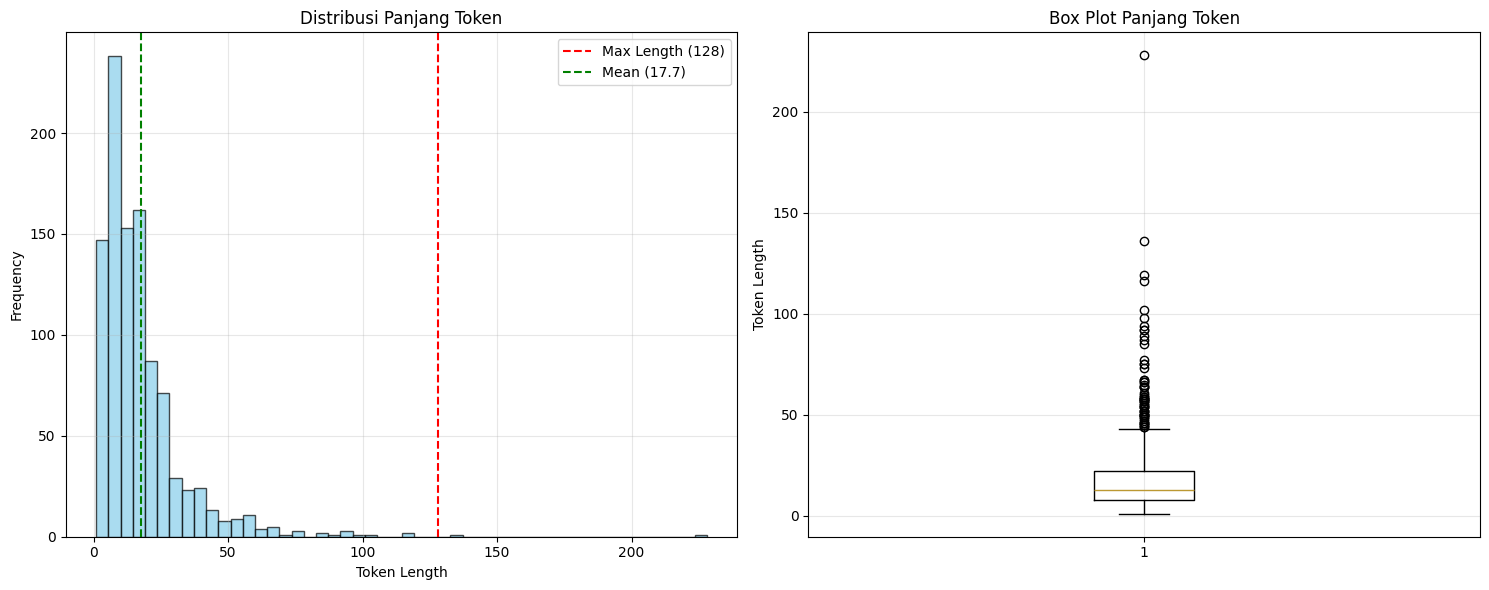


=== DEMONSTRASI TOKENISASI ===

--- Contoh 1 ---
Text: "alhamdulillah berfungsi dengan baik packaging aman respon cepat dan ramah seller dan kurir amanah"
Length: 97 characters
Tokens (14): ['alhamdulillah', 'berfungsi', 'dengan', 'baik', 'packaging', 'aman', 'respon', 'cepat', 'dan', 'ramah', 'seller', 'dan', 'kurir', 'amanah']
Token IDs: [5742, 2942, 79, 342, 29520, 1703, 5040, 972, 41, 4782, 15076, 41, 12065, 10651]
Full encoding (max_len=20):
  Input IDs: [2, 5742, 2942, 79, 342, 29520, 1703, 5040, 972, 41, 4782, 15076, 41, 12065, 10651, 3, 0, 0, 0, 0]
  Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
  Decoded: "alhamdulillah berfungsi dengan baik packaging aman respon cepat dan ramah seller dan kurir amanah"
Special tokens:
  [CLS]: [CLS] (ID: 2)
  [SEP]: [SEP] (ID: 3)
  [PAD]: [PAD] (ID: 0)
  [UNK]: [UNK] (ID: 1)

--- Contoh 2 ---
Text: "barang bagus segel utuh original berfungsi dengan benar seller respon nya ajib cepat amir uda begitu kasi saranny

In [7]:
# Cell 5: Tokenizer Setup and Analysis
def setup_tokenizer_and_analyze(df_clean):
    print("="*60)
    print("SETUP TOKENIZER DAN ANALISIS")
    print("="*60)
    print(f"Loading tokenizer: {Config.MODEL_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)
    print(f"✓ Tokenizer loaded successfully!")
    print(f"  Vocab size: {tokenizer.vocab_size:,}")
    print(f"  Model max length: {tokenizer.model_max_length}")
    analyze_tokenization(tokenizer, df_clean)
    demonstrate_tokenization(tokenizer, df_clean)
    return tokenizer

def analyze_tokenization(tokenizer, df_clean):
    print("\n=== ANALISIS TOKENISASI ===")
    sample_size = min(1000, len(df_clean))
    sample_texts = df_clean['processed_review'].sample(n=sample_size, random_state=42).tolist()
    token_lengths = []
    word_counts = []
    print(f"Menganalisis {sample_size} samples...")
    for text in sample_texts:
        tokens = tokenizer.tokenize(text)
        token_lengths.append(len(tokens))
        words = text.split()
        word_counts.append(len(words))
    print("\nStatistik Token Length:")
    print(f"  Mean: {np.mean(token_lengths):.1f}")
    print(f"  Median: {np.median(token_lengths):.1f}")
    print(f"  Std: {np.std(token_lengths):.1f}")
    print(f"  Min: {np.min(token_lengths)}")
    print(f"  Max: {np.max(token_lengths)}")
    print(f"  95th percentile: {np.percentile(token_lengths, 95):.1f}")
    print(f"  99th percentile: {np.percentile(token_lengths, 99):.1f}")
    for max_len in [64, 128, 256, 512]:
        truncated_pct = (np.array(token_lengths) > max_len).mean() * 100
        print(f"  Data truncated at {max_len}: {truncated_pct:.1f}%")
    print("\nStatistik Word Count:")
    print(f"  Mean: {np.mean(word_counts):.1f}")
    print(f"  Ratio tokens/words: {np.mean(token_lengths)/np.mean(word_counts):.2f}")
    plot_token_distribution(token_lengths)
    return token_lengths

def plot_token_distribution(token_lengths):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].hist(token_lengths, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0].axvline(Config.MAX_LENGTH, color='red', linestyle='--',
                    label=f'Max Length ({Config.MAX_LENGTH})')
    axes[0].axvline(np.mean(token_lengths), color='green', linestyle='--',
                    label=f'Mean ({np.mean(token_lengths):.1f})')
    axes[0].set_xlabel('Token Length')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribusi Panjang Token')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].boxplot(token_lengths)
    axes[1].set_ylabel('Token Length')
    axes[1].set_title('Box Plot Panjang Token')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{Config.RESULTS_PATH}/token_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

def demonstrate_tokenization(tokenizer, df_clean):
    print("\n=== DEMONSTRASI TOKENISASI ===")
    sample_texts = [
        df_clean['processed_review'].iloc[0],
        df_clean[df_clean['processed_review'].str.len() > 100]['processed_review'].iloc[0],
        df_clean[df_clean['Emotion'] == 'Anger']['processed_review'].iloc[0]
    ]
    for i, text in enumerate(sample_texts, 1):
        print(f"\n--- Contoh {i} ---")
        print(f"Text: \"{text}\"")
        print(f"Length: {len(text)} characters")
        tokens = tokenizer.tokenize(text)
        print(f"Tokens ({len(tokens)}): {tokens}")
        token_ids = tokenizer.convert_tokens_to_ids(tokens)
        print(f"Token IDs: {token_ids}")
        encoding = tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=20,
            return_tensors='pt'
        )
        print(f"Full encoding (max_len=20):")
        print(f"  Input IDs: {encoding['input_ids'][0].tolist()}")
        print(f"  Attention Mask: {encoding['attention_mask'][0].tolist()}")
        decoded = tokenizer.decode(encoding['input_ids'][0], skip_special_tokens=True)
        print(f"  Decoded: \"{decoded}\"")
        print(f"Special tokens:")
        print(f"  [CLS]: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
        print(f"  [SEP]: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})")
        print(f"  [PAD]: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
        print(f"  [UNK]: {tokenizer.unk_token} (ID: {tokenizer.unk_token_id})")

tokenizer = setup_tokenizer_and_analyze(df_clean)


In [8]:
# Cell 6: Custom Dataset Class
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        assert len(texts) == len(labels)
        print(f"Dataset created with {len(texts)} samples")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            add_special_tokens=True
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [9]:
# Cell 7: Data Preparation (Lengkap dengan Oversampling)
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

def print_label_distribution(y, label_encoder, dataset_name):
    """Fungsi helper untuk mencetak distribusi label."""
    unique, counts = np.unique(y, return_counts=True)
    print(f"\nDistribusi {dataset_name}:")
    for label_idx, count in zip(unique, counts):
        emotion = label_encoder.classes_[label_idx]
        percentage = (count / len(y)) * 100
        print(f"  {emotion}: {count:,} ({percentage:.1f}%)")

def prepare_datasets_oversampled(df_clean, tokenizer, label_encoder):
    print("="*60)
    print("PREPARE DATASETS DENGAN RANDOM OVERSAMPLING")
    print("="*60)
    X = df_clean['processed_review'].values
    y = df_clean['emotion_label'].values

    # Split data menjadi train dan test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=Config.TEST_SIZE, random_state=Config.RANDOM_STATE, stratify=y)

    # Split lagi data train untuk mendapatkan data validasi
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=Config.VAL_SIZE, random_state=Config.RANDOM_STATE, stratify=y_train)

    print_label_distribution(y_train, label_encoder, "Training set (SEBELUM Oversampling)")

    # Menerapkan RandomOverSampler HANYA pada data training
    ros = RandomOverSampler(random_state=Config.RANDOM_STATE)
    X_train_reshaped = np.array(X_train).reshape(-1, 1)
    X_train_res, y_train_res = ros.fit_resample(X_train_reshaped, y_train)
    X_train_res = X_train_res.flatten()

    print_label_distribution(y_train_res, label_encoder, "Training set (SETELAH Oversampling)")

    # 4. Buat dataset PyTorch dari data yang sudah diproses
    train_dataset = EmotionDataset(X_train_res, y_train_res, tokenizer, Config.MAX_LENGTH)
    val_dataset = EmotionDataset(X_val, y_val, tokenizer, Config.MAX_LENGTH)
    test_dataset = EmotionDataset(X_test, y_test, tokenizer, Config.MAX_LENGTH)

    return train_dataset, val_dataset, test_dataset, (X_test, y_test)

train_dataset, val_dataset, test_dataset, (X_test, y_test) = prepare_datasets_oversampled(df_clean, tokenizer, label_encoder)

PREPARE DATASETS DENGAN RANDOM OVERSAMPLING

Distribusi Training set (SEBELUM Oversampling):
  Anger: 481 (12.7%)
  Fear: 640 (16.9%)
  Happy: 1,249 (33.1%)
  Love: 560 (14.8%)
  Sadness: 849 (22.5%)

Distribusi Training set (SETELAH Oversampling):
  Anger: 1,249 (20.0%)
  Fear: 1,249 (20.0%)
  Happy: 1,249 (20.0%)
  Love: 1,249 (20.0%)
  Sadness: 1,249 (20.0%)
Dataset created with 6245 samples
Dataset created with 420 samples
Dataset created with 1050 samples


In [10]:
# Cell 8: Model Setup


def setup_model(num_labels, device):
    print("="*60)
    print("SETUP MODEL")
    print("="*60)
    print(f"Loading model: {Config.MODEL_NAME}")
    print(f"Number of labels: {num_labels}")
    model = AutoModelForSequenceClassification.from_pretrained(
        Config.MODEL_NAME,
        num_labels=num_labels,
        output_attentions=False,
        output_hidden_states=False,
    )
    model.to(device)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✓ Model loaded successfully!")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Model size: ~{total_params * 4 / 1e6:.1f} MB")
    print(f"\nModel architecture:")
    print(f"  Base model: BERT")
    print(f"  Hidden size: {model.config.hidden_size}")
    print(f"  Number of layers: {model.config.num_hidden_layers}")
    print(f"  Number of attention heads: {model.config.num_attention_heads}")
    print(f"  Vocab size: {model.config.vocab_size}")
    print(f"  Max position embeddings: {model.config.max_position_embeddings}")
    return model

def model_init(trial):
    return AutoModelForSequenceClassification.from_pretrained(
        Config.MODEL_NAME,
        num_labels=num_labels
    )
num_labels = len(label_encoder.classes_)
model = setup_model(num_labels, device)


SETUP MODEL
Loading model: indobenchmark/indobert-large-p2
Number of labels: 5


pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-large-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded successfully!
  Total parameters: 335,147,013
  Trainable parameters: 335,147,013
  Model size: ~1340.6 MB

Model architecture:
  Base model: BERT
  Hidden size: 1024
  Number of layers: 24
  Number of attention heads: 16
  Vocab size: 30522
  Max position embeddings: 512


In [ ]:
# Cell 9: Menjalankan Hyperparameter Search pada Data Oversampled (Skenario 1.2)
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from optuna.samplers import GridSampler
def get_training_arguments():
    return TrainingArguments(
        output_dir=Config.LOGS_PATH,
        num_train_epochs=Config.NUM_EPOCHS,
        per_device_train_batch_size=Config.BATCH_SIZE,
        per_device_eval_batch_size=Config.EVAL_BATCH_SIZE,
        learning_rate=Config.LEARNING_RATE,
        warmup_ratio=Config.WARMUP_RATIO,
        weight_decay=Config.WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        load_best_model_at_end=False,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=True,
        report_to="none"
    )

def run_hyperparameter_search_on_oversampled(train_dataset, val_dataset, device):
    print("="*60)
    print("MENJALANKAN GRID SEARCH PADA DATA OVERSAMPLED")
    print("="*60)

    training_args = get_training_arguments()

    # Gunakan Trainer standar karena tidak butuh Class Weights
    trainer = Trainer(
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        model_init=model_init
    )

    def my_hp_space(trial):
          return {
              "learning_rate": trial.suggest_categorical("learning_rate", [4e-5, 3e-5, 2e-5]),
              "num_train_epochs": trial.suggest_categorical("num_train_epochs", [5, 7, 10]),
              "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32]),
              "per_device_eval_batch_size": trial.suggest_categorical("per_device_eval_batch_size", [16, 32]),
          }

      # Definisikan search space terpisah untuk GridSampler
    search_space_for_sampler = {
        "learning_rate": [4e-5, 3e-5, 2e-5],
        "num_train_epochs": [5, 7, 10],
        "per_device_train_batch_size": [16, 32],
        "per_device_eval_batch_size": [16, 32],
    }

    print("🚀 Memulai pencarian hyperparameter dengan GridSampler...")
    best_trial = trainer.hyperparameter_search(
        direction="minimize",
        backend="optuna",
        hp_space=my_hp_space,                      # Gunakan fungsi yang benar
        sampler=GridSampler(search_space_for_sampler), # GridSampler masih butuh ini
        n_trials=36
    )

    print("\n✅ Pencarian Selesai!")
    print("Hyperparameter terbaik yang ditemukan:")
    print(best_trial.hyperparameters)

    return best_trial.hyperparameters


train_dataset_os, val_dataset_os, test_dataset_os, (X_test_os, y_test_os) = prepare_datasets_oversampled(
    df_clean, tokenizer, label_encoder
)

best_params = run_hyperparameter_search_on_oversampled(train_dataset_os, val_dataset_os, device)

PREPARE DATASETS DENGAN RANDOM OVERSAMPLING

Distribusi Training set (SEBELUM Oversampling):
  Anger: 481 (12.7%)
  Fear: 640 (16.9%)
  Happy: 1,249 (33.1%)
  Love: 560 (14.8%)
  Sadness: 849 (22.5%)

Distribusi Training set (SETELAH Oversampling):
  Anger: 1,249 (20.0%)
  Fear: 1,249 (20.0%)
  Happy: 1,249 (20.0%)
  Love: 1,249 (20.0%)
  Sadness: 1,249 (20.0%)
Dataset created with 6245 samples
Dataset created with 420 samples
Dataset created with 1050 samples
MENJALANKAN GRID SEARCH PADA DATA OVERSAMPLED


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-large-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-11-26 12:46:11,588] A new study created in memory with name: no-name-46cf5ca8-3c97-45d4-900d-96cf008a9bbf


🚀 Memulai pencarian hyperparameter dengan GridSampler...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-large-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,1.103500,0.754541
2,0.441900,0.785334
3,0.166300,1.097340
4,0.062000,1.495274
5,0.017800,1.827729
6,0.008000,1.919684
7,0.003600,1.950711


...

Epoch,Training Loss,Validation Loss
1,1.030300,0.743245


[I 2025-11-26 17:37:38,227] Trial 31 pruned. 
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-large-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,1.045200,0.828925


[I 2025-11-26 17:39:27,919] Trial 32 pruned. 
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-large-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,1.061300,0.744703


2f0a1b937bb4a4bf968518c810a923321ebfb39b

In [ ]:
# Cell 9.5: Melatih Model Final dengan Hyperparameter Terbaik (Oversampled)

print("\n" + "="*60)
print("MELATIH MODEL FINAL DENGAN HYPERPARAMETER TERBAIK (OVERSAMPLED)")
print("="*60)

# Buat TrainingArguments baru dengan parameter terbaik
final_training_args = TrainingArguments(
    output_dir=f"{Config.MODEL_SAVE_PATH}_best_oversampled",
    learning_rate=best_params['learning_rate'],
    num_train_epochs=best_params['num_train_epochs'],
    per_device_train_batch_size=best_params['per_device_train_batch_size'],
    per_device_eval_batch_size=best_params['per_device_eval_batch_size'],
    warmup_ratio=Config.WARMUP_RATIO,
    weight_decay=Config.WEIGHT_DECAY,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    report_to="none"
)


final_trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=train_dataset, # Gunakan dataset yang sudah di-oversampling
    eval_dataset=val_dataset
)

# Latih model final
final_trainer.train()
tokenizer.save_pretrained(final_training_args.output_dir)
print("\nModel terbaik (Skenario 1.2) siap untuk dievaluasi.")


MELATIH MODEL FINAL DENGAN HYPERPARAMETER TERBAIK (OVERSAMPLED)


Epoch,Training Loss,Validation Loss
1,0.935000,0.740675
2,0.358100,0.847063
3,0.111300,1.257459
4,0.040100,1.615524
5,0.007800,1.741125



Model terbaik (Skenario 1.2) siap untuk dievaluasi.


MODEL EVALUATION
Making predictions on test set...



Test Accuracy: 0.7038 (70.38%)

Classification Report:
              precision    recall  f1-score   support

       Anger       0.60      0.61      0.61       134
        Fear       0.58      0.47      0.52       178
       Happy       0.84      0.83      0.84       347
        Love       0.67      0.70      0.69       155
     Sadness       0.66      0.74      0.70       236

    accuracy                           0.70      1050
   macro avg       0.67      0.67      0.67      1050
weighted avg       0.70      0.70      0.70      1050



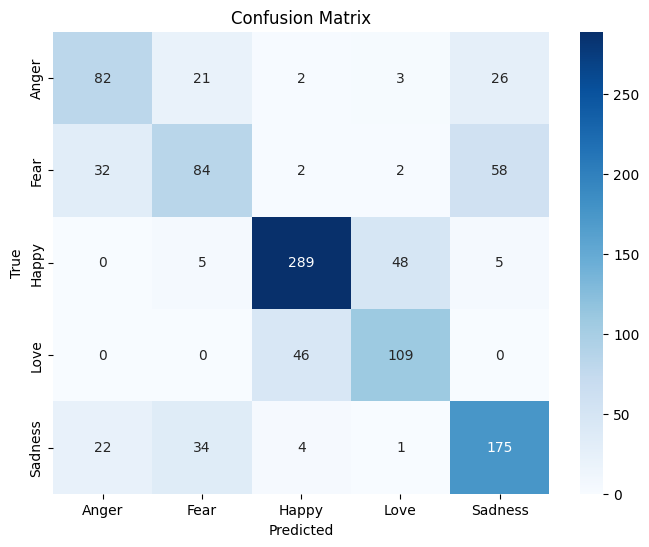


Analisis kesalahan disimpan di: /content/drive/MyDrive/hasil_sken2/results/error_analysis.csv
Contoh kesalahan prediksi:
                                                 text true_label  \
1   belanja kedua kalinya selalu puas pengiriman l...      Happy   
2   lama pengiriman atc di hari itu juga tapi gak ...      Anger   
5   penjual tidak membaca catatan yang diberikan p...    Sadness   
6   tidak sesuai pesanan yang di pesan gula 1kg ke...       Fear   
12  pengiriman cepat tapi qualitas barangnya jelek...      Anger   
16  memang sih murah barangnya tapi boleh lah iya ...       Fear   
22           packing hancur sampai lebur sampai rumah    Sadness   
33  bagian dalam berantakan semua benang nya seand...       Fear   
39  barang kondisi diterima baik dan aman saran sa...      Happy   
40  gak fungsi walau sudah di charge seharian sial...    Sadness   

   predicted_label  
1             Love  
2             Fear  
5             Fear  
6          Sadness  
12         Sadness  
16 

In [12]:
# Cell 10: Evaluation
def evaluate_model(trainer, test_dataset, X_test, y_test, label_encoder):
    print("="*60)
    print("MODEL EVALUATION")
    print("="*60)
    print("Making predictions on test set...")
    predictions = final_trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()
    y_true = y_test
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    target_names = label_encoder.classes_
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names))
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # Buat DataFrame untuk analisis kesalahan
    df_analysis = pd.DataFrame({
        'text': X_test,
        'true_label': label_encoder.inverse_transform(y_true),
        'predicted_label': label_encoder.inverse_transform(y_pred)
    })

    # Filter hanya untuk prediksi yang salah
    df_errors = df_analysis[df_analysis['true_label'] != df_analysis['predicted_label']]

    # Simpan ke file CSV untuk dianalisis
    error_report_path = f'{Config.RESULTS_PATH}/error_analysis.csv'
    df_errors.to_csv(error_report_path, index=False)

    print(f"\nAnalisis kesalahan disimpan di: {error_report_path}")
    print("Contoh kesalahan prediksi:")
    print(df_errors.head(10))
    return accuracy

accuracy = evaluate_model(final_trainer, test_dataset, X_test, y_test, label_encoder)



In [13]:
# Cell 11: Prediction Function
def predict_emotion(text, model, tokenizer, label_encoder, device, max_length=128):
    processed_text = preprocess_bert_friendly(text)
    if len(processed_text) == 0:
        return {
            'emotion': 'Unknown',
            'confidence': 0.0,
            'all_probabilities': {emotion: 0.0 for emotion in label_encoder.classes_}
        }
    encoding = tokenizer(
        processed_text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    encoding = {k: v.to(device) for k, v in encoding.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**encoding)
        predictions = F.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(predictions, dim=-1).item()
        confidence = predictions[0][predicted_class].item()
    emotion = label_encoder.classes_[predicted_class]
    all_probs = {
        label_encoder.classes_[i]: predictions[0][i].item()
        for i in range(len(label_encoder.classes_))
    }
    return {
        'emotion': emotion,
        'confidence': confidence,
        'all_probabilities': all_probs,
        'processed_text': processed_text
    }

# Example usage
test_text = "Padahal berharap bagus, tapi hsilnya mengecewakan"
result = predict_emotion(test_text, model, tokenizer, label_encoder, device)
print(f"Text: \"{test_text}\"")
print(f"Predicted Emotion: {result['emotion']} (confidence: {result['confidence']:.3f})")
print("\nAll Probabilities:")
for emotion, prob in result['all_probabilities'].items():
    print(f"  {emotion}: {prob:.3f}")


Text: "Padahal berharap bagus, tapi hsilnya mengecewakan"
Predicted Emotion: Sadness (confidence: 0.955)

All Probabilities:
  Anger: 0.022
  Fear: 0.016
  Happy: 0.006
  Love: 0.001
  Sadness: 0.955
